Accuracy: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36


Feature Importance:
alcohol : 0.0
malic_acid : 0.0187
ash : 0.0202
alcalinity_of_ash : 0.0209
magnesium : 0.0
total_phenols : 0.0
flavanoids : 0.4081
nonflavanoid_phenols : 0.0
proanthocyanins : 0.0
color_intensity : 0.4002
hue : 0.0
od280/od315_of_diluted_wines : 0.021
proline : 0.111


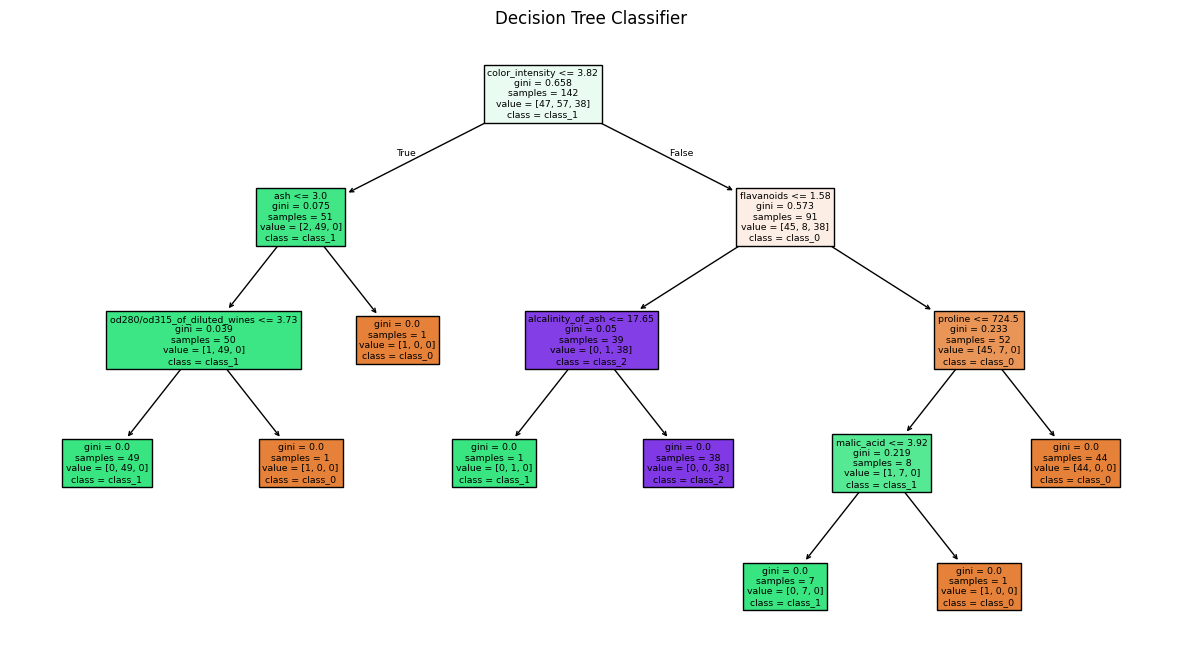

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

data = load_wine()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
importance = model.feature_importances_

print("\nFeature Importance:")

for feature, value in zip(data.feature_names, importance):
    print(feature, ":", round(value, 4))

# Visualize tree
plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()